In [123]:
import os, random, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

tf.keras.mixed_precision.set_global_policy("mixed_float16")

In [ ]:
#CONFIGURATIONS
IMAGE_SIZE      = 224
BATCH_SIZE      = 64
NUM_CLASSES     = 101
AUTOTUNE        = tf.data.AUTOTUNE

VAL_SPLIT = 0.10

# Head training
HEAD_EPOCHS     = 5
HEAD_LR         = 2e-3

# Fine-tune LR schedule
FINETUNE_EPOCHS     = 30
LR_START            = 1e-5
LR_MAX              = 8e-4
LR_MIN              = 1e-7
LR_RAMPUP_EPOCHS    = 5
LR_SUSTAIN_EPOCHS   = 0
LR_EXP_DECAY        = 0.87
WEIGHT_DECAY        = 1e-4

# Random seeds
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
#Download Dataset
dataset_url = "http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz"
data_dir = tf.keras.utils.get_file("food-101.tar.gz", origin=dataset_url, extract=True)
data_dir = Path(data_dir).parent / "food-101_extracted" / "food-101"

images_dir = data_dir / "images"
meta_dir   = data_dir / "meta"

4996278331/4996278331 ━━━━━━━━━━━━━━━━━━━━ 238s 0us/step


In [ ]:
#Splitting Data
def load_split(meta_file: Path, images_root: Path):
    lines       = meta_file.read_text().strip().splitlines() #OUTPUT: classlabels/image_filename (without ".jpg" extension)
    class_names = sorted({l.split("/")[0] for l in lines})
    class_to_idx = {c: i for i, c in enumerate(class_names)} #Each values are the last index of each class.

    paths, labels = [], []
    for line in lines:
        cls, imgs = line.split("/")
        fpath = str(images_root / cls / (imgs + ".jpg"))
        paths.append(fpath)
        labels.append(class_to_idx[cls])

    return paths, labels, class_names

#Splitting via Dataset's original split.
train_paths, train_labels, CLASS_NAMES = load_split(
    meta_dir / "train.txt", images_dir
)

original_val_paths, original_val_labels, _ = load_split(
    meta_dir / "test.txt", images_dir
)
#Splitting test and val set from original test.
val_paths, test_paths, val_labels, test_labels = train_test_split(
    original_val_paths,
    original_val_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=original_val_labels
)

print(f"Train samples : {len(train_paths)}")
print(f"Val   samples : {len(val_paths)}")
print(f"Test  samples : {len(test_paths)}")

Train samples : 75750
Val   samples : 12625
Test  samples : 12625


In [ ]:
#Functions
def decode_image(path: tf.Tensor) -> tf.Tensor:
    raw   = tf.io.read_file(path)
    image = tf.image.decode_jpeg(raw, channels=3) #decode raw jpg.
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE]) #Resize
    image = tf.cast(image, tf.float32)
    return image

def augment(image: tf.Tensor) -> tf.Tensor:
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)

    # Random crop
    pad   = int(IMAGE_SIZE * 0.06)
    image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE + pad, IMAGE_SIZE + pad)
    image = tf.image.random_crop(image, [IMAGE_SIZE, IMAGE_SIZE, 3])

    #Colour (Important for food dataset because food photos are taken from different brightness, contrast, saturation etc.)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)
    return image

def visualize_augmentation(paths: list, n: int=8, save_dir: str = "./images"): 
  os.makedirs(save_dir, exist_ok=True)
  chosen = random.sample(paths, n) #Choosing random images

  fig,axes = plt.subplots(2, n, figsize=(3 * n, 6))
  fig.suptitle("Data Augmentation: Before (top) vs After (bottom)", fontsize=14)

  for col, path in enumerate(chosen): #Same process as making dataset (3 functions below)
    image = decode_image(path)
    aug = augment(image)

    axes[0, col].imshow(image.numpy())
    axes[0, col].axis("off")
    axes[0, col].set_title(Path(path).parent.name, fontsize=7)

    axes[1, col].imshow(aug.numpy())
    axes[1, col].axis("off")

  plt.tight_layout()
  out = os.path.join(save_dir, "augmentation_preview.jpg")
  plt.savefig(out, dpi=120)
  plt.show()
  print(f"Augmentation preview saved -> {out}")

def plot(history_dict: dict, model_name: str, phase: str, save_dir: str = "./images"):
  if hasattr(history_dict, "history"):
    history_dict = history_dict.history
  os.makedirs(save_dir, exist_ok=True)

  acc       = history_dict.get("accuracy", [])
  val_acc   = history_dict.get("val_accuracy", [])
  loss      = history_dict.get("loss", [])
  val_loss  = history_dict.get("val_loss", [])

  min_len = min(len(acc), len(val_acc), len(loss), len(val_loss))
  acc = acc[:min_len]
  val_acc = val_acc[:min_len]
  loss = loss[:min_len]
  val_loss = val_loss[:min_len]

  epochs_range = range(1, min_len + 1)

  plt.figure(figsize=(15, 6))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc,     label="Training Accuracy",   marker="o")
  plt.plot(epochs_range, val_acc, label="Validation Accuracy", marker="x")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.title(f"{model_name} — {phase} — Accuracy")
  plt.legend(loc="lower right")
  plt.grid(True)

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss,     label="Training Loss",   marker="o")
  plt.plot(epochs_range, val_loss, label="Validation Loss", marker="x")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title(f"{model_name} — {phase} — Loss")
  plt.legend(loc="upper right")
  plt.grid(True)

  plt.tight_layout()
  plot_filename = os.path.join(save_dir, f"{model_name.lower()}_{phase.lower()}_metrics.jpg")
  plt.savefig(plot_filename, dpi=120)
  plt.show()
  print(f"Plot saved → {plot_filename}")

def backup_model(model_name: str, phase: str, save_dir: str = "./plots"):
  checkpoint_model = f"food101_best_{model_name}.keras"
  filename         = f"food101_{model_name}_{phase}.keras"
  drive_path       = os.path.join("/content/drive/MyDrive/Food101", filename)
  plot_file = os.path.join(save_dir, f"{model_name.lower()}_{phase.lower()}_metrics.jpg")
  plot_name = f"{model_name.lower()}_{phase.lower()}_metrics.jpg"
  save_file = os.path.join("/content/drive/MyDrive/Food101/Plots", plot_name)
  if os.path.exists(checkpoint_model):
      shutil.copy(checkpoint_model, drive_path)
      if os.path.exists(plot_file):
          shutil.copy(plot_file, save_file)
      print(f"[backup] {model_name}/{phase} saved to Drive!")
  else:
      print(f"[backup] ERROR — {checkpoint_model} not found.")

'''
#Key idea

Training: shuffle -> read, decode, resize -> data augmentation ->preprocess function -> batching
Test: read,decode,resize -> preprocess function -> batching -> label_formating

'''


def make_dataset(paths: list,labels: list,*,training: bool, preprocess_fn, batch_size: int = BATCH_SIZE,) -> tf.data.Dataset:

  ds = tf.data.Dataset.from_tensor_slices((paths, labels))
  if training:
    ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
  ds = ds.map(lambda p, l: (decode_image(p), l), num_parallel_calls=AUTOTUNE,) 
  if training:
    ds = ds.map(lambda img, lbl: (augment(img),lbl), num_parallel_calls=AUTOTUNE,)

  ds = ds.map(lambda img, lbl: (preprocess_fn(img), lbl), num_parallel_calls=AUTOTUNE)

  ds = ds.batch(batch_size, drop_remainder=training)
  ds = ds.map(lambda imgs, lbls: (imgs, tf.one_hot(lbls, NUM_CLASSES)), num_parallel_calls=AUTOTUNE,)
  return ds.prefetch(AUTOTUNE)

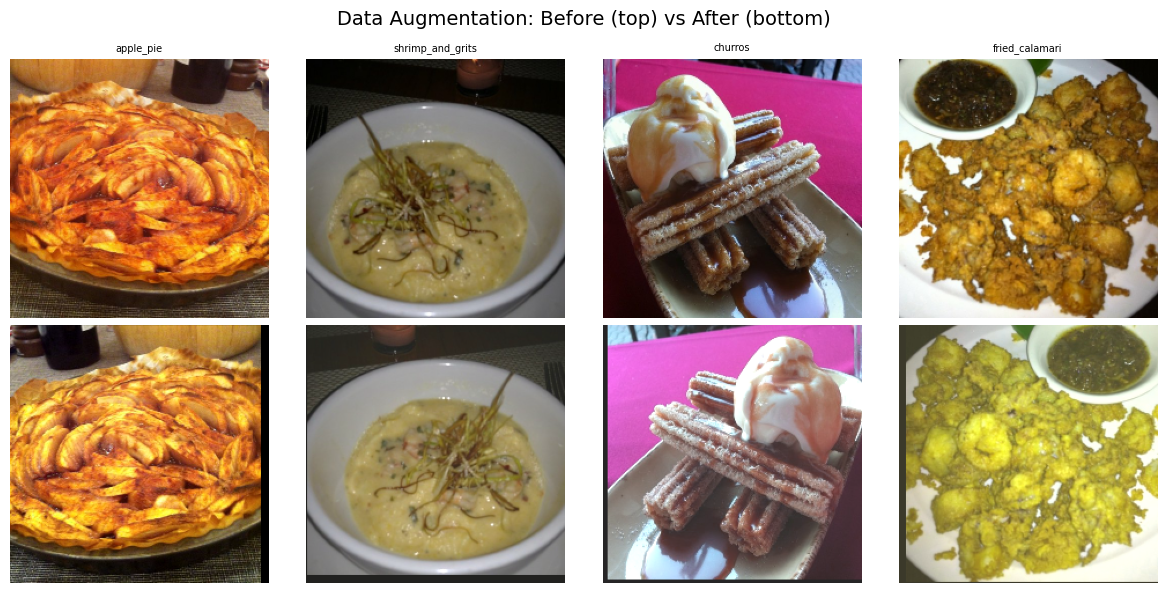

Augmentation preview saved -> ./plots/augmentation_preview.jpg


In [126]:
visualize_augmentation(paths=train_paths, n=4)

In [ ]:
#Building Model
def build_model(base_model_fn, base_model_name:str):
  inp = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32, name="image_input",)

  base_model = base_model_fn(include_top=False, weights='imagenet', input_tensor=inp, pooling=None,)
  base_model._name = base_model_name
  base_model.trainable=False
  freeze_bn(base_model)

  feature = base_model.output
  feature = layers.GlobalAveragePooling2D(name=f"{base_model_name}_gap")(feature)
  feature = layers.BatchNormalization(name=f"{base_model_name}_bn")(feature)
  feature = layers.Dropout(0.5, name=f"{base_model_name}_drop")(feature)
  out = layers.Dense(NUM_CLASSES, activation='softmax', dtype="float32", name=f"{base_model_name}_out")(feature)

  model = keras.Model(inputs=inp, outputs=out, name=f"food101_{base_model_name}")
  return model, base_model

'''
key structure:
input layer
base_model
global average pooling
batch normalization
dropout
dense(101 + softmax)
'''

In [ ]:
# Setting up Variables and Functions for model.compile() & model.fit(callbacks)
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
metrics = [
    keras.metrics.CategoricalAccuracy(name="accuracy"),
    keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy"),
]

def lrfn(epoch: int) -> float: #For Custom Learning Rate Schedule(Taken from Practical Machine Learning for Computer Vision textbook)
    if epoch < LR_RAMPUP_EPOCHS:
        lr = (LR_MAX - LR_START) / LR_RAMPUP_EPOCHS * epoch + LR_START
    elif epoch < LR_RAMPUP_EPOCHS + LR_SUSTAIN_EPOCHS:
        lr = LR_MAX
    else:
        decay_epochs = epoch - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS
        lr = (LR_MAX - LR_MIN) * (LR_EXP_DECAY ** decay_epochs) + LR_MIN
    return float(lr)

lr_callback = keras.callbacks.LearningRateScheduler(lrfn, verbose=True)

def callbacks(model_name: str, stage: str):
  return [
      keras.callbacks.ModelCheckpoint(
          filepath=f"food101_best_{model_name}.keras",
          monitor="val_loss",
          save_best_only=True,
          verbose=1,
      ),
      keras.callbacks.EarlyStopping(
          monitor="val_loss",
          patience=5,
          restore_best_weights=True,
          verbose=1,
      )
  ]

In [ ]:
#Functions Spcifically for Custom Fine Tuning Step
DENSENET_BLOCK_GROUPS = [
    ["conv5_block", "bn", "relu"],
    ["conv4_block", "pool4_"],
    ["conv3_block", "pool3_", "conv2_block", "pool2_", "conv1_", "pool1"],
]

def unfreeze_phase(base_model, phase:int):
  for i in range(phase + 1):
    _set_block_trainable(base_model, DENSENET_BLOCK_GROUPS[i], trainable=True)
  freeze_bn(base_model)

def _set_block_trainable(base_model, block_prefixes: list, trainable:bool):
  for layer in base_model.layers:
    if any(layer.name.startswith(p) for p in block_prefixes):
      if isinstance(layer, layers.BatchNormalization):
        layer.trainable=False
      else:
        layer.trainable=trainable

def freeze_bn(model):
  for layer in model.layers:
    if isinstance(layer, layers.BatchNormalization) or "bn" in layer.name.lower():
      layer.trainable=False

Learning rate schedule: 1e-05 to 0.0008 to 2.84e-05


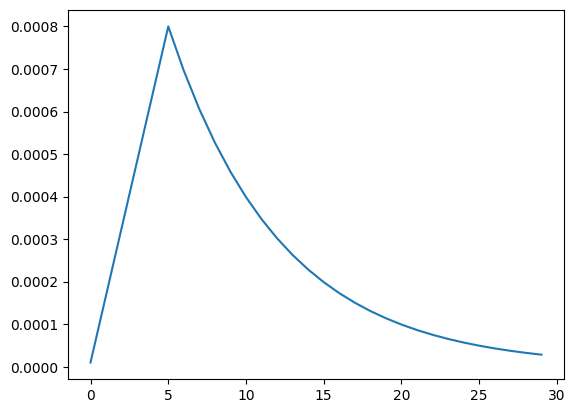

In [84]:
# Visualization for LR Schedule
rng = [i for i in range(FINETUNE_EPOCHS)]
y = [lrfn(x) for x in rng]
plt.plot(rng, y)
print("Learning rate schedule: {:.3g} to {:.3g} to {:.3g}".format(y[0], max(y), y[-1]))

In [ ]:
#Making Dataset (I moved here because preprocessing step is included in the dataset creation, so it's easier to change for different models.)
train_ds = make_dataset(train_paths, train_labels, training=True, preprocess_fn=keras.applications.densenet.preprocess_input)
val_ds = make_dataset(val_paths, val_labels, training=False, preprocess_fn=keras.applications.densenet.preprocess_input)
test_ds = make_dataset(test_paths, test_labels, training=False, preprocess_fn=keras.applications.densenet.preprocess_input)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches: {len(val_ds)}")
print(f"Test batches {len(test_ds)}")

Train batches : 1183
Val batches: 198
Test batches 198


In [ ]:
#DenseNet - Classification Head Training
model, base_model = build_model(keras.applications.DenseNet201, "densenet201")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LR),
    loss=loss_fn,
    metrics=metrics,
)
history_head_densenet201 = model.fit(
    train_ds,
    epochs=HEAD_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks("densenet201","head"),
    verbose=1
)

Epoch 1/5
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3693 - loss: 3.1404 - top5_accuracy: 0.6209
Epoch 1: val_loss improved from None to 1.97211, saving model to food101_best_densenet201.keras

Epoch 1: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 184s 116ms/step - accuracy: 0.4489 - loss: 2.7970 - top5_accuracy: 0.7126 - val_accuracy: 0.6678 - val_loss: 1.9721 - val_top5_accuracy: 0.8893
Epoch 2/5
1182/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5302 - loss: 2.4467 - top5_accuracy: 0.7895
Epoch 2: val_loss improved from 1.97211 to 1.91998, saving model to food101_best_densenet201.keras

Epoch 2: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 88s 74ms/step - accuracy: 0.5322 - loss: 2.4411 - top5_accuracy: 0.7897 - val_accuracy: 0.6901 - val_loss: 1.9200 - val_top5_accuracy: 0.9014
Epoch 3/5
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5628 - loss: 2.3372 - top5_accura

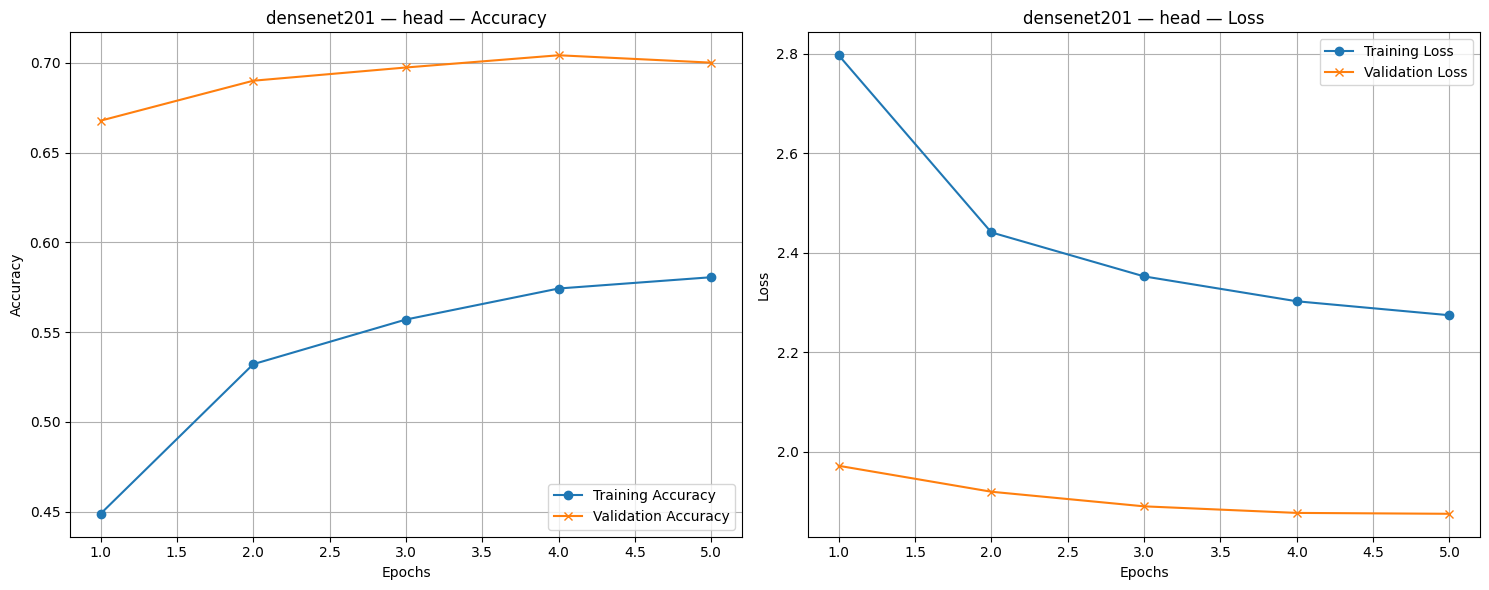

Plot saved → ./plots/densenet201_head_metrics.jpg


In [93]:
plot(history_head_densenet201, "densenet201", "head")
drive.mount('/content/drive')
backup_model("densenet201", "head")

In [ ]:
#DenseNet201 - Fine Tuning - Phase 1 (Top Blocks)

history_ft_densenet201 = {} # since I'm training for three phase, I need to store them

# Load the best model from head training
model = keras.models.load_model(f"food101_best_densenet201.keras", compile=False)

phase = 0 #I know that it's wrong naming system :)
unfreeze_phase(model, phase=phase)

lr = lrfn(0) # Since we'll start from epoch 0 for this stage.

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate = lr,
        weight_decay=WEIGHT_DECAY
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_stage = model.fit(
    train_ds,
    epochs=10, # Run for 10 epochs for this phase (epochs 0-9)
    initial_epoch=0,
    validation_data=val_ds,
    callbacks=[
        lr_callback,
        *callbacks("densenet201", "finetune_phase1"),
    ],
    verbose=1,
)
for key, value in history_stage.history.items():
  history_ft_densenet201.setdefault(key, []).extend(value)



Epoch 1: LearningRateScheduler setting learning rate to 1e-05.
Epoch 1/10
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6461 - loss: 2.1599 - top5_accuracy: 0.8687
Epoch 1: val_loss improved from None to 1.76599, saving model to food101_best_densenet201.keras

Epoch 1: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 224s 124ms/step - accuracy: 0.6363 - loss: 2.1333 - top5_accuracy: 0.8613 - val_accuracy: 0.7355 - val_loss: 1.7660 - val_top5_accuracy: 0.9229 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 0.000168.
Epoch 2/10
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5968 - loss: 2.2058 - top5_accuracy: 0.8400
Epoch 2: val_loss improved from 1.76599 to 1.68902, saving model to food101_best_densenet201.keras

Epoch 2: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 99s 83ms/step - accuracy: 0.6152 - loss: 2.1530 - top5_accuracy: 0.8498 - val_accu

In [ ]:
#DenseNet201 - Fine Tuning - Phase 2 (Middle Blocks)

# Load the best model from previous phase
model = keras.models.load_model(f"food101_best_densenet201.keras", compile=False)

# Phase 2 setup
phase = 1 # Unfreeze middle blocks
unfreeze_phase(model, phase=phase)

lr = lrfn(10) # Starting from epoch 10 for this stage

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate = lr,
        weight_decay=WEIGHT_DECAY
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_stage = model.fit(
    train_ds,
    epochs=20, # Run from epoch 10 to 20 (10 epochs for this phase: 10-19)
    initial_epoch=10,
    validation_data=val_ds,
    callbacks=[
        lr_callback,
        *callbacks("densenet201", "finetune_phase2"),
    ],
    verbose=1,
)
for key, value in history_stage.history.items():
  history_ft_densenet201.setdefault(key, []).extend(value)


Epoch 11: LearningRateScheduler setting learning rate to 0.00039878689446793005.
Epoch 11/20
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6410 - loss: 2.4182 - top5_accuracy: 0.8538
Epoch 11: val_loss improved from None to 1.69049, saving model to food101_best_densenet201.keras

Epoch 11: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 300s 158ms/step - accuracy: 0.6342 - loss: 2.1701 - top5_accuracy: 0.8570 - val_accuracy: 0.7407 - val_loss: 1.6905 - val_top5_accuracy: 0.9266 - learning_rate: 3.9879e-04

Epoch 12: LearningRateScheduler setting learning rate to 0.00034695759818709914.
Epoch 12/20
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7053 - loss: 1.8336 - top5_accuracy: 0.9051
Epoch 12: val_loss improved from 1.69049 to 1.59593, saving model to food101_best_densenet201.keras

Epoch 12: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 139s 117ms/step - accuracy: 0.7057 - loss

In [ ]:
#DenseNet201 - Fine Tuning - Phase 3 (Full Base Model)

# Load the best model from previous phase
model = keras.models.load_model(f"food101_best_densenet201.keras", compile=False)

# Phase 3 setup
phase = 2 # Unfreeze full base model
unfreeze_phase(model, phase=phase)

lr = lrfn(20) # Starting from epoch 20 for this stage

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate = lr,
        weight_decay=WEIGHT_DECAY
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_stage = model.fit(
    train_ds,
    epochs=30, # Run from epoch 20 to 30 (10 epochs for this phase: 20-29)
    initial_epoch=20,
    validation_data=val_ds,
    callbacks=[
        lr_callback,
        *callbacks("densenet201", "finetune_phase3"),
    ],
    verbose=1,
)
for key, value in history_stage.history.items():
  history_ft_densenet201.setdefault(key, []).extend(value)


Epoch 21: LearningRateScheduler setting learning rate to 9.914315951710379e-05.
Epoch 21/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8702 - loss: 1.2503 - top5_accuracy: 0.9768
Epoch 21: val_loss improved from None to 1.44437, saving model to food101_best_densenet201.keras

Epoch 21: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 425s 199ms/step - accuracy: 0.8820 - loss: 1.2504 - top5_accuracy: 0.9802 - val_accuracy: 0.8119 - val_loss: 1.4444 - val_top5_accuracy: 0.9542 - learning_rate: 9.9143e-05

Epoch 22: LearningRateScheduler setting learning rate to 8.62675487798803e-05.
Epoch 22/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9127 - loss: 1.1853 - top5_accuracy: 0.9878
Epoch 22: val_loss improved from 1.44437 to 1.43282, saving model to food101_best_densenet201.keras

Epoch 22: finished saving model to food101_best_densenet201.keras
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 188s 159ms/step - accuracy: 0.9111 - loss: 1

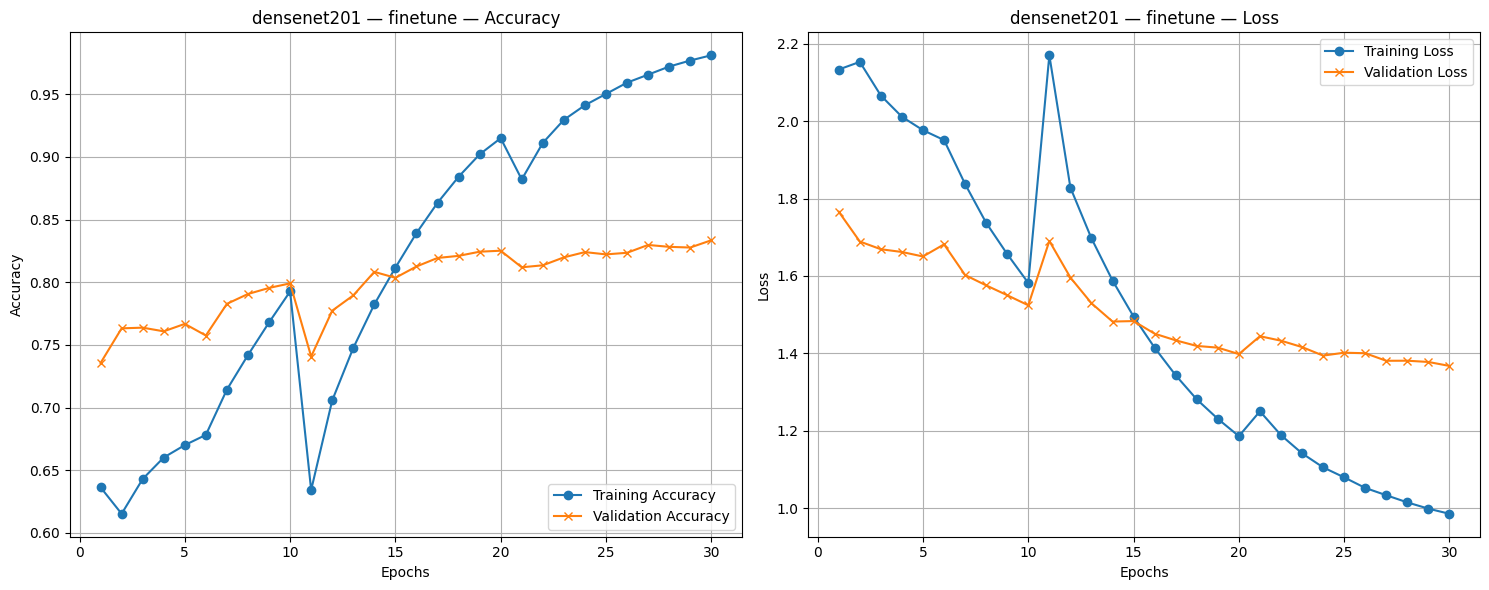

Plot saved → ./plots/densenet201_finetune_metrics.jpg


In [94]:
plot(history_ft_densenet201, "densenet201", "finetune")
backup_model("densenet201", "finetune")

In [ ]:
def ds_to_labels(ds: tf.data.Dataset) -> np.ndarray:
    all_labels = []
    for _, lbls in ds:
        all_labels.append(np.argmax(lbls.numpy(), axis=-1))
    return np.concatenate(all_labels)

test_true = ds_to_labels(test_ds)
print(test_true)

array([93, 84, 26, ..., 58, 19, 35])

In [ ]:
predictions = np.argmax(model.predict(test_ds), axis=1)

198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step


### Evaluations

In [95]:
results = model.evaluate(test_ds, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1]*100))
print("Test Top 5 Accuracy: {:.2f}%".format(results[2]*100))

Test Accuracy: 83.24%
Test Top 5 Accuracy: 95.87%


In [103]:
f1 = f1_score(test_true, predictions, average="macro")
precision = precision_score(test_true, predictions, average="macro")
recall = recall_score(test_true, predictions, average="macro")

print(f"Test F1-Score: {f1*100:.2f}%")
print(f"Test Precision: {precision*100:.2f}%")
print(f"Test Recall: {recall*100:.2f}%")

Test F1-Score: 83.20%
Test Precision: 83.35%
Test Recall: 83.24%


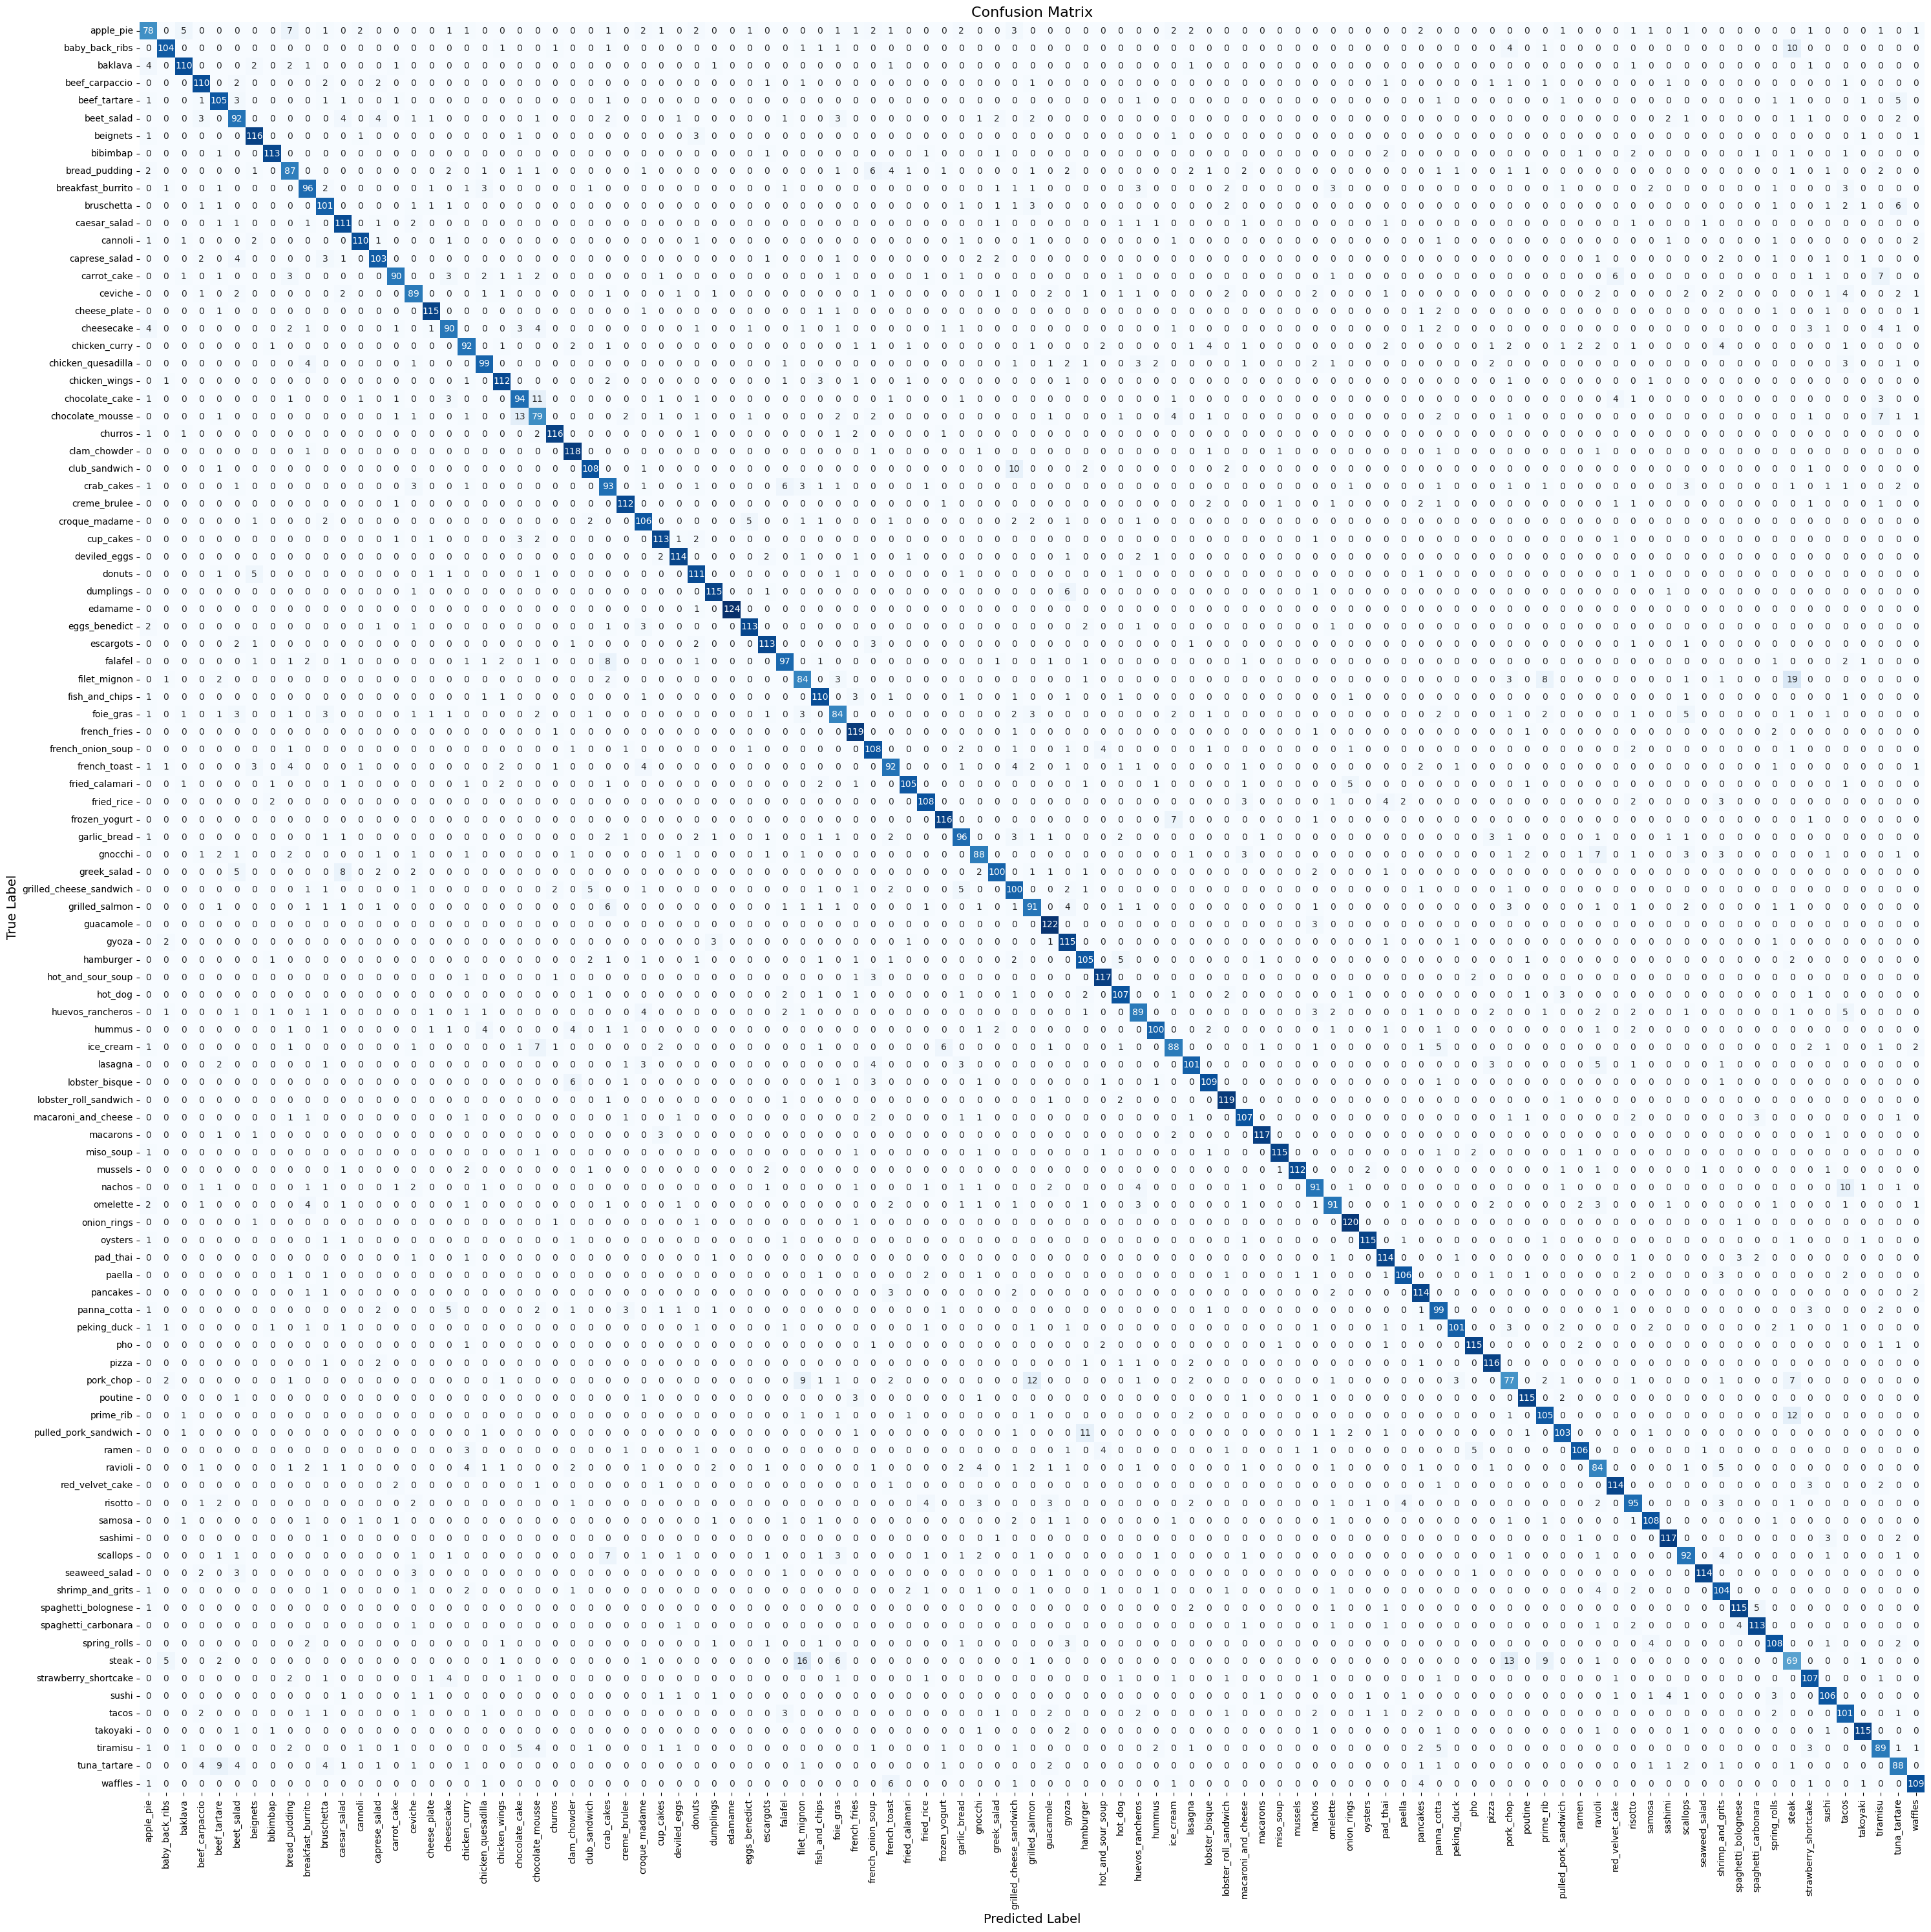

In [97]:
cm = confusion_matrix(test_true, predictions)

plt.figure(figsize=(30,30))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False, annot_kws={'fontsize': 10})
plt.yticks(ticks=np.arange(NUM_CLASSES) + 0.5, labels=CLASS_NAMES, rotation=0, fontsize=10)
plt.xticks(ticks=np.arange(NUM_CLASSES) + 0.5, labels=CLASS_NAMES, rotation=90, fontsize=10)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()